# Online Retail II

## Load Dataset

In [1]:
# Load the Online Retail II dataset into a DataFrame.
# This dataset will be used to validate whether it supports customer segmentation, CLV analysis, 
# churn prediction, purchase prediction, and recommendation-related analytics.

import pandas as pd

df = pd.read_csv(
    "online_retail_II.csv",
    encoding="ISO-8859-1"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Dataset Overview

In [2]:
# Examine the overall structure of the dataset,
# including the number of rows, columns,
# and a sample of the data.

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape:
(1067371, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Check for missing values in each column.
# This helps assess data quality and identify
# fields that may require cleaning before analysis.

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [4]:
# Review key dataset characteristics including:
# - Date range
# - Number of unique customers
# - Number of unique products
# - Number of invoices

print("Date Range:")
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

print("\nUnique Customers:")
print(df["Customer ID"].nunique())

print("\nUnique Products:")
print(df["StockCode"].nunique())

print("\nUnique Invoices:")
print(df["Invoice"].nunique())

Date Range:
2009-12-01 07:45:00
2011-12-09 12:50:00

Unique Customers:
5942

Unique Products:
5305

Unique Invoices:
53628


## Data Cleaning

In [5]:
# Remove records with missing Customer IDs,
# convert InvoiceDate to datetime format,
# calculate transaction revenue,
# and remove invalid transactions
# with negative quantities or prices.

df_clean = df.dropna(subset=["Customer ID"]).copy()

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
]

print("Cleaned Shape:")
print(df_clean.shape)

display(df_clean.head())

Cleaned Shape:
(805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [6]:
# Remove records with missing Customer IDs,
# convert InvoiceDate to datetime format,
# calculate transaction revenue,
# and remove invalid transactions
# with negative quantities or prices.

print("Cleaned Date Range:")
print(df_clean["InvoiceDate"].min())
print(df_clean["InvoiceDate"].max())

print("\nCleaned Unique Customers:")
print(df_clean["Customer ID"].nunique())

print("\nCleaned Unique Invoices:")
print(df_clean["Invoice"].nunique())

print("\nCleaned Unique Products:")
print(df_clean["StockCode"].nunique())

print("\nTotal Revenue:")
print(df_clean["Revenue"].sum())

Cleaned Date Range:
2009-12-01 07:45:00
2011-12-09 12:50:00

Cleaned Unique Customers:
5878

Cleaned Unique Invoices:
36969

Cleaned Unique Products:
4631

Total Revenue:
17743429.178000003


## Repeat Purchase Analysis

In [7]:
# Analyze customer purchasing frequency.
# Repeat purchase behavior is an important indicator
# for evaluating the feasibility of CLV analysis,
# churn prediction, and purchase prediction models.

customer_orders = df_clean.groupby("Customer ID")["Invoice"].nunique()

print("Customer Order Count Summary:")
print(customer_orders.describe())

one_time_customers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()
total_customers = len(customer_orders)

print("\nOne-time Customers:")
print(one_time_customers)

print("\nRepeat Customers:")
print(repeat_customers)

print("\nOne-time Customer Percentage:")
print(one_time_customers / total_customers * 100)

print("\nRepeat Customer Percentage:")
print(repeat_customers / total_customers * 100)

Customer Order Count Summary:
count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

One-time Customers:
1623

Repeat Customers:
4255

One-time Customer Percentage:
27.611432460020414

Repeat Customer Percentage:
72.38856753997959


## Country Distribution Analysis

In [8]:
# Identify the geographic distribution of transactions.
# This helps determine whether country-level
# comparisons and statistical testing are feasible.

df_clean["Country"].value_counts().head(10)

Country
United Kingdom    725250
Germany            16694
EIRE               15743
France             13812
Netherlands         5088
Spain               3719
Belgium             3068
Switzerland         3011
Portugal            2446
Australia           1812
Name: count, dtype: int64

## Customer Revenue Analysis

In [9]:
# Identify high-value customers by calculating
# total revenue generated by each customer.
# This analysis supports customer segmentation
# and CLV-related business insights.

customer_revenue = (
    df_clean.groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

In [20]:
# Calculate customer purchase frequency

customer_frequency = (
    df_clean.groupby("Customer ID")["Invoice"]
    .nunique()
)

customer_frequency.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

## Revenue Distribution

In [21]:
customer_revenue.describe()

count      5878.000000
mean       3018.616737
std       14737.731040
min           2.950000
25%         348.762500
50%         898.915000
75%        2307.090000
max      608821.650000
Name: Revenue, dtype: float64

## Customer Activity Timeline

C:\Users\Administrator\AppData\Local\Temp\ipykernel_57016\1696465431.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Invoice"]


<Axes: xlabel='InvoiceDate'>

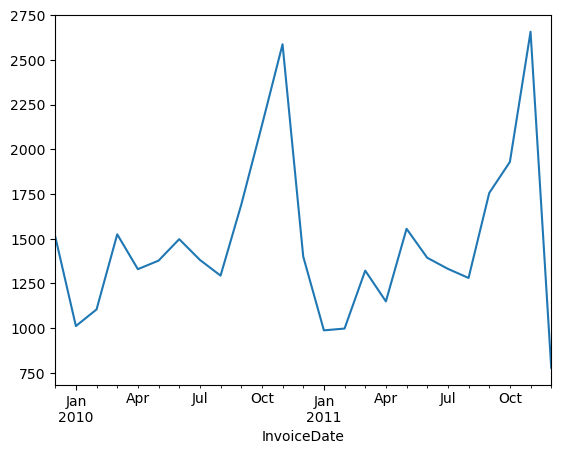

In [22]:
monthly_orders = (
    df_clean
    .set_index("InvoiceDate")
    .resample("M")["Invoice"]
    .nunique()
)

monthly_orders.plot()

In [23]:
basket_size = (
    df_clean.groupby("Invoice")["StockCode"]
    .nunique()
)

multi_invoice = (basket_size > 1).sum()

print(multi_invoice)
print(multi_invoice / len(basket_size) * 100)

33897
91.69033514566259


# Olist

## Load Dataset

In [10]:
# Load the key Olist datasets needed for recommendation feasibility checking.
# We use orders, order items, and customers because market basket recommendation
# requires order-level product interactions.

import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")

## Check Dataset Size and Columns

In [11]:
# Check the number of rows and columns for each dataset.
# This helps verify that the files were loaded correctly
# and gives us the basic scale of the data.

print("Orders shape:")
print(orders.shape)

print("\nOrders columns:")
print(orders.columns.tolist())

print("\nOrder Items shape:")
print(items.shape)

print("\nOrder Items columns:")
print(items.columns.tolist())

print("\nCustomers shape:")
print(customers.shape)

print("\nCustomers columns:")
print(customers.columns.tolist())

Orders shape:
(99441, 8)

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Order Items shape:
(112650, 7)

Order Items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Customers shape:
(99441, 5)

Customers columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [12]:
# Display sample rows from each dataset.
# This is useful for confirming the key fields we will use,
# such as order_id, customer_id, and product_id.

print("Orders sample:")
display(orders.head())

print("Order Items sample:")
display(items.head())

print("Customers sample:")
display(customers.head())

Orders sample:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Order Items sample:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Customers sample:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## Missing Value

In [14]:
# Check missing values in each dataset.
# This helps assess whether the key fields needed for recommendation
# have missing or incomplete records.

print("Missing values in orders:")
print(orders.isnull().sum())

print("\nMissing values in order items:")
print(items.isnull().sum())

print("\nMissing values in customers:")
print(customers.isnull().sum())

Missing values in orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing values in order items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing values in customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


## Check Key IDs

In [15]:
# Check the availability of key IDs.
# For market basket analysis, we need order_id and product_id.
# For customer-level linkage, we need customer_id.

print("Unique orders in orders table:")
print(orders["order_id"].nunique())

print("\nUnique orders in items table:")
print(items["order_id"].nunique())

print("\nUnique products in items table:")
print(items["product_id"].nunique())

print("\nUnique customers in orders table:")
print(orders["customer_id"].nunique())

print("\nUnique customers in customers table:")
print(customers["customer_id"].nunique())

Unique orders in orders table:
99441

Unique orders in items table:
98666

Unique products in items table:
32951

Unique customers in orders table:
99441

Unique customers in customers table:
99441


## Merge orders and order items

In [16]:
# Merge orders with order items using order_id.
# This creates an order-product interaction dataset,
# which is the core structure needed for market basket recommendation.

order_product = items.merge(
    orders[["order_id", "customer_id", "order_purchase_timestamp", "order_status"]],
    on="order_id",
    how="left"
)

print("Merged order-product shape:")
print(order_product.shape)

display(order_product.head())

Merged order-product shape:
(112650, 10)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,order_status
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,delivered
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,delivered
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,delivered
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,delivered
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,delivered


## Check Complete Orders Only

In [17]:
# Keep only delivered orders because they represent completed purchases.
# This avoids including canceled or unavailable orders in recommendation analysis.

order_product_clean = order_product[
    order_product["order_status"] == "delivered"
].copy()

print("Delivered order-product shape:")
print(order_product_clean.shape)

print("\nUnique delivered orders:")
print(order_product_clean["order_id"].nunique())

print("\nUnique delivered customers:")
print(order_product_clean["customer_id"].nunique())

print("\nUnique delivered products:")
print(order_product_clean["product_id"].nunique())

Delivered order-product shape:
(110197, 10)

Unique delivered orders:
96478

Unique delivered customers:
96478

Unique delivered products:
32216


## Check Basket Size

In [18]:
# Calculate how many different products appear in each order.
# Market basket analysis works best when some orders contain multiple products.
# If most orders contain only one product, recommendation may still be possible,
# but association rules will be weaker.

basket_size = (
    order_product_clean.groupby("order_id")["product_id"]
    .nunique()
)

print("Basket size summary:")
print(basket_size.describe())

multi_product_orders = (basket_size > 1).sum()
total_orders = len(basket_size)

print("\nOrders with more than one product:")
print(multi_product_orders)

print("\nPercentage of multi-product orders:")
print(multi_product_orders / total_orders * 100)

Basket size summary:
count    96478.000000
mean         1.038537
std          0.227942
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: product_id, dtype: float64

Orders with more than one product:
3197

Percentage of multi-product orders:
3.313708824809801


In [19]:
# Identify the most frequently purchased products.
# This helps assess whether product-level recommendation
# and product popularity analysis are feasible.

top_products = (
    order_product_clean.groupby("product_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

top_products.head(10)

product_id
99a4788cb24856965c36a24e339b6058    456
aca2eb7d00ea1a7b8ebd4e68314663af    425
422879e10f46682990de24d770e7f83d    352
d1c427060a0f73f6b889a5c7c61f2ac4    313
389d119b48cf3043d311335e499d9c6b    309
53b36df67ebb7c41585e8d54d6772e08    304
368c6c730842d78016ad823897a372db    291
53759a2ecddad2bb87a079a1f1519f73    287
154e7e31ebfa092203795c972e5804a6    262
2b4609f8948be18874494203496bc318    254
Name: order_id, dtype: int64